# Tarea 2 --- IELE756: Health Landscape - ENO + GRD
**Integrantes**: Darío Ampuero, Nicolás Véliz
**Comunas asignadas**: Independencia, Recoleta, Padre Hurtado, San Pedro
**Fecha**: 16 de abril de 2026

## Introducción y Objetivos
En este trabajo analizaremos el perfil epidemiológico y hospitalario de cuatro comunas de la Región Metropolitana con realidades sociodemográficas muy distintas. Utilizaremos dos fuentes de datos críticas:
1. **ENO**: Vigilancia de enfermedades de notificación obligatoria (2007-2024).
2. **GRD**: Registros de egresos hospitalarios (2022-2024).

El objetivo es identificar patrones de salud, comparar el perfil de carga de enfermedad entre la población nacional y extranjera, y generar tablas resumen para un posterior análisis multivariable en la Tarea 3.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
import geopandas as gpd

# Configuración visual
sns.set_theme(style="whitegrid")

# --- CÓDIGOS OFICIALES SEGÚN DICCIONARIO Y FEEDBACK ---
# Independencia (13108), Recoleta (13127), Padre Hurtado (13604), San Pedro (13505)
MY_COMUNAS_NUM = [13108, 13127, 13604, 13505]
MY_COMUNAS_STR_ENO = [str(c) for c in MY_COMUNAS_NUM]
MY_COMUNAS_STR_GRD = ["INDEPENDENCIA", "RECOLETA", "PADRE HURTADO", "SAN PEDRO"]

# Diccionario de nombres para etiquetas
nombre_map = {13108: "Independencia", 13127: "Recoleta", 13604: "Padre Hurtado", 13505: "San Pedro"}

print(f"Entorno configurado para las comunas: {list(nombre_map.values())}")

Entorno configurado para las comunas: ['Independencia', 'Recoleta', 'Padre Hurtado', 'San Pedro']


## Part A: ENO - Notifiable Diseases
### A.0 Carga y Limpieza
Cargaremos los datos de ENO. Es vital mencionar que una limitación estructural de esta base es la anonimización de la comuna en el 45% de los registros (`*****`). Por lo tanto, cualquier conteo comunal debe entenderse como un **subconteo** de la carga real de notificaciones.

In [2]:
print("Procesando base ENO...")
eno_cols = ["ENO", "anho_notificacion", "codigo_comuna_residencia", "nacionalidad", "sexo", "grupo_edad"]

# Carga flexible (semicolon y encoding utf-8-sig)
eno = pd.read_csv("20241218_base_eno_final.csv", sep=";", encoding="utf-8-sig", usecols=eno_cols, low_memory=False)

# Reportar anonimizados
anon_rows = (eno["codigo_comuna_residencia"] == "*****").sum()
print(f"Alerta: {anon_rows:,} registros anonimizados (*****) detectados en la base total.")

# Filtrar por nuestras comunas (usando strings para mayor seguridad)
eno_com = eno[eno["codigo_comuna_residencia"].isin(MY_COMUNAS_STR_ENO)].copy()
print(f"Registros en nuestras comunas: {len(eno_com):,}")

# Limpiar Nacionalidad (Excluir 'Desconocido' para análisis específicos)
eno_valido = eno_com[eno_com["nacionalidad"] != "Desconocido"].copy()
print(f"Distribución inicial de nacionalidad:\n{eno_com['nacionalidad'].value_counts()}")

Procesando base ENO...
Alerta: 148,217 registros anonimizados (*****) detectados en la base total.
Registros en nuestras comunas: 4,688
Distribución inicial de nacionalidad:
nacionalidad
Chile          1796
Desconocido    1542
Extranjero     1350
Name: count, dtype: int64


### A.1 Tendencias y Perfiles de Enfermedad
Analizaremos cómo han evolucionado las notificaciones. Se espera observar un impacto significativo durante el periodo 2020-2022 debido a la pandemia de COVID-19, tanto por la enfermedad en sí como por el efecto de "túnel" en la vigilancia de otras patologías.

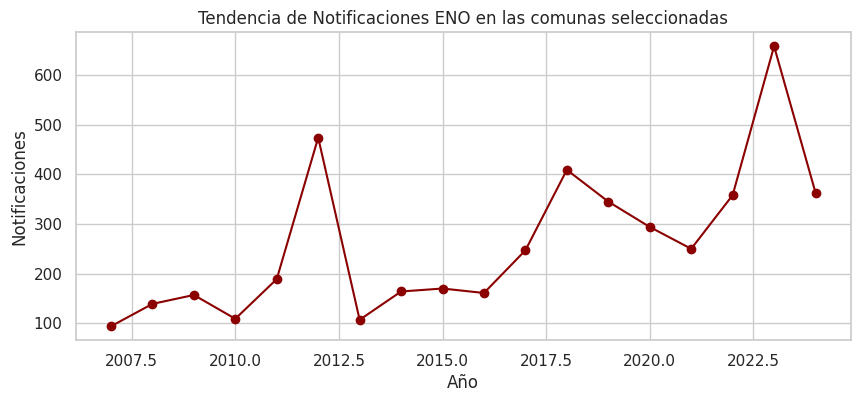

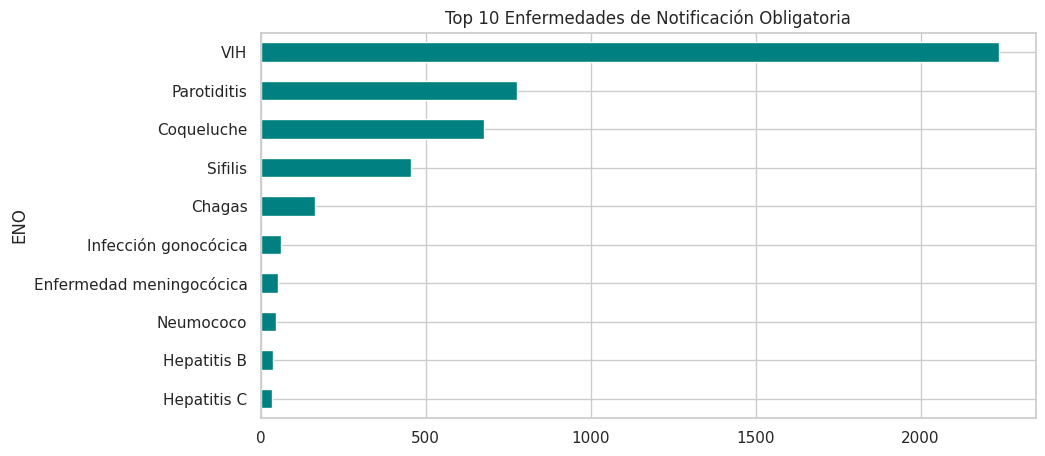

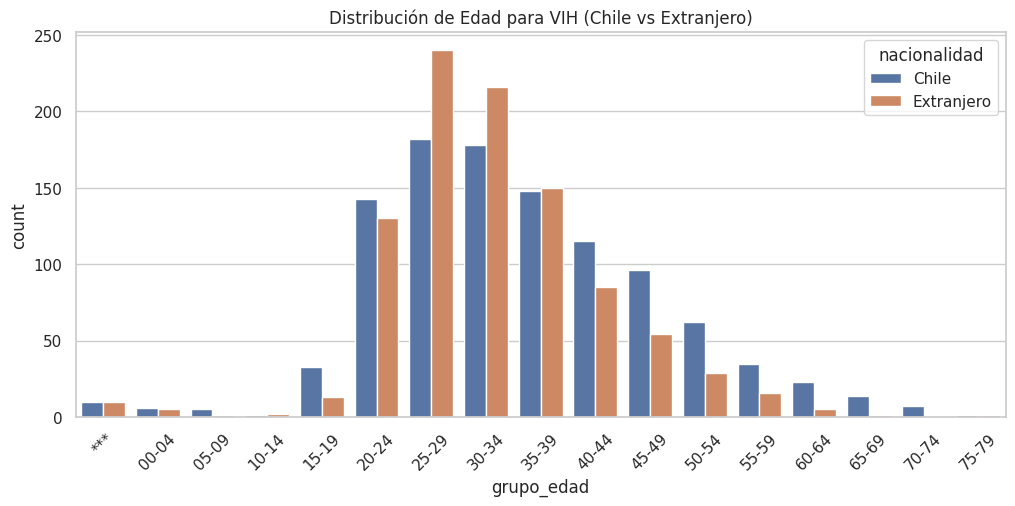

In [3]:
# A.1.1 Tendencia General
plt.figure(figsize=(10, 4))
eno_com.groupby("anho_notificacion").size().plot(kind="line", marker="o", color="darkred")
plt.title("Tendencia de Notificaciones ENO en las comunas seleccionadas")
plt.xlabel("Año"); plt.ylabel("Notificaciones"); plt.show()

# A.2.1 Top 10 Enfermedades
plt.figure(figsize=(10, 5))
eno_com["ENO"].value_counts().head(10).sort_values().plot(kind="barh", color="teal")
plt.title("Top 10 Enfermedades de Notificación Obligatoria")
plt.show()

# A.2.3 Distribución por Edad para la enfermedad Top 1
top_enf = eno_com["ENO"].mode()[0]
plt.figure(figsize=(12, 5))
sns.countplot(data=eno_valido[eno_valido["ENO"] == top_enf].sort_values("grupo_edad"),
              x="grupo_edad", hue="nacionalidad")
plt.title(f"Distribución de Edad para {top_enf} (Chile vs Extranjero)")
plt.xticks(rotation=45); plt.show()

## Part B: GRD - Hospital Discharges
### B.0 Carga y Limpieza Robusta
A diferencia de ENO, los archivos GRD presentan inconsistencias de codificación (`UTF-16` en 2022/23 vs `Latin-1` en 2024). Nuestro código implementa una carga dual para asegurar la integridad de los datos. Calcularemos el *Length of Stay* (LOS) y uniremos los registros con el diccionario CIE-10 para identificar capítulos diagnósticos.

In [4]:
print("Procesando archivos GRD (2022-2024)...")
grd_cols = ["COMUNA", "NACIONALIDAD", "FECHA_INGRESO", "FECHAALTA", "DIAGNOSTICO1", "IR_29301_SEVERIDAD", "TIPOALTA"]
frames = []

for y in [2022, 2023, 2024]:
    fname = "GRD_PUBLICO_EXTERNO_2022" if y == 2022 else f"GRD_PUBLICO_{y}"
    fpath = f"{fname}.txt"
    if os.path.exists(fpath):
        try:
            # Intento 1: Latin-1
            df_y = pd.read_csv(fpath, sep="|", usecols=grd_cols, encoding="latin-1", low_memory=False)
            if 'COMUNA' not in df_y.columns: raise ValueError
        except:
            # Intento 2: UTF-16
            df_y = pd.read_csv(fpath, sep="|", usecols=grd_cols, encoding="utf-16", low_memory=False)
        frames.append(df_y)

if frames:
    grd = pd.concat(frames, ignore_index=True)
    grd_com = grd[grd["COMUNA"].isin(MY_COMUNAS_STR_GRD)].copy()

    # B.0.3 Length of Stay (los)
    grd_com["FECHA_INGRESO"] = pd.to_datetime(grd_com["FECHA_INGRESO"], dayfirst=True, errors="coerce")
    grd_com["FECHAALTA"] = pd.to_datetime(grd_com["FECHAALTA"], dayfirst=True, errors="coerce")
    grd_com["los"] = (grd_com["FECHAALTA"] - grd_com["FECHA_INGRESO"]).dt.days
    grd_com = grd_com[grd_com["los"] >= 0].copy() # Eliminar errores

    # B.0.4 Nationality Grouping
    grd_com["nat_group"] = np.where(grd_com["NACIONALIDAD"] == "CHILE", "Chilean", "Foreign")

    # B.0.5 Join CIE-10
    if os.path.exists("CIE-10.xlsx"):
        cie10 = pd.read_excel("CIE-10.xlsx", sheet_name="CIE 10").drop_duplicates("Código")
        grd_com = grd_com.merge(cie10[["Código", "Descripción", "Capítulo"]], left_on="DIAGNOSTICO1", right_on="Código", how="left")

    print(f"Base GRD lista con {len(grd_com):,} hospitalizaciones válidas.")

Procesando archivos GRD (2022-2024)...


/tmp/ipykernel_3087/2957938474.py:23: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  grd_com["FECHA_INGRESO"] = pd.to_datetime(grd_com["FECHA_INGRESO"], dayfirst=True, errors="coerce")
/tmp/ipykernel_3087/2957938474.py:24: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  grd_com["FECHAALTA"] = pd.to_datetime(grd_com["FECHAALTA"], dayfirst=True, errors="coerce")


Base GRD lista con 30,127 hospitalizaciones válidas.


### B.1 Perfil Diagnóstico y Severidad
Analizamos los capítulos de hospitalización predominantes. Esperamos que capítulos como el de enfermedades respiratorias o circulatorias dominen, pero también prestaremos atención a las diferencias en severidad (`IR_29301_SEVERIDAD`) entre grupos, lo cual podría indicar barreras de acceso (llegada más tardía al hospital) para ciertos grupos de población.

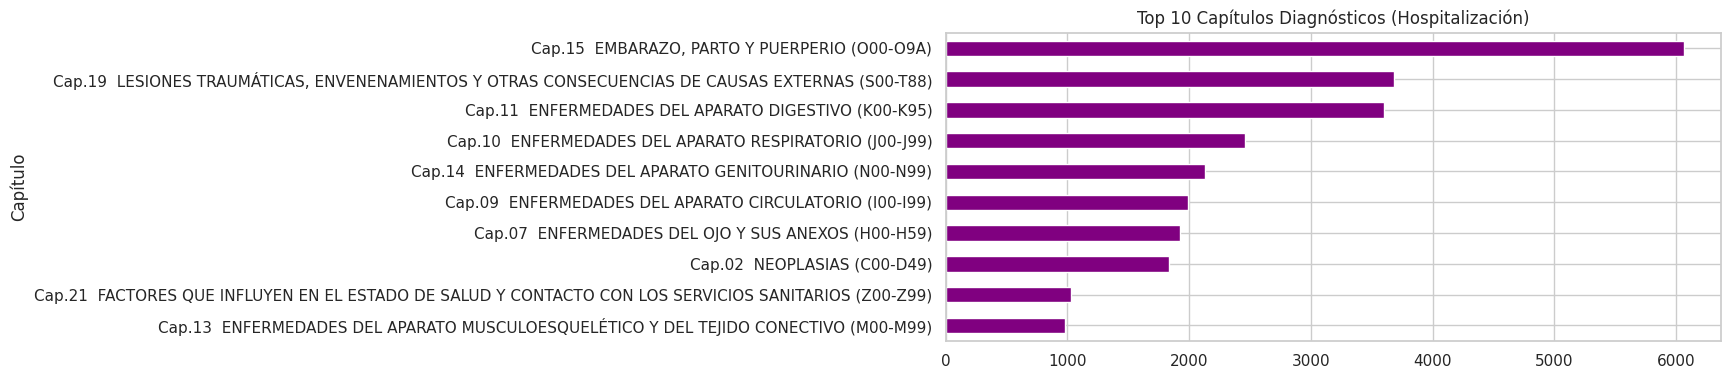

/tmp/ipykernel_3087/3577819888.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grd_com[grd_com["los"] <= 30], x="los", y="nat_group", palette="Set2")


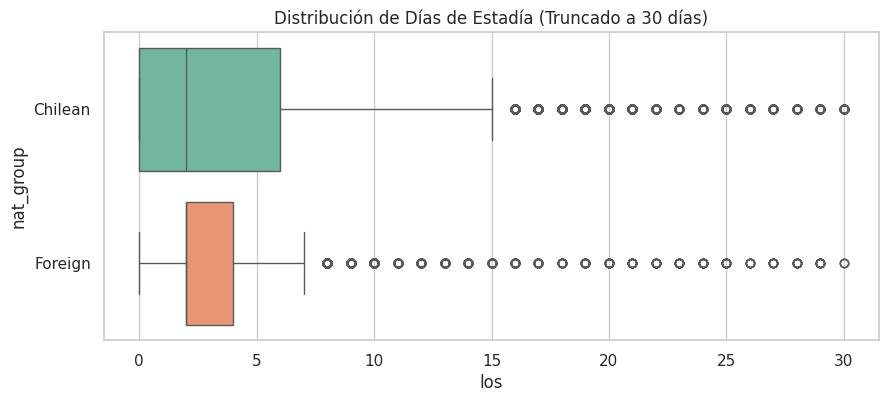

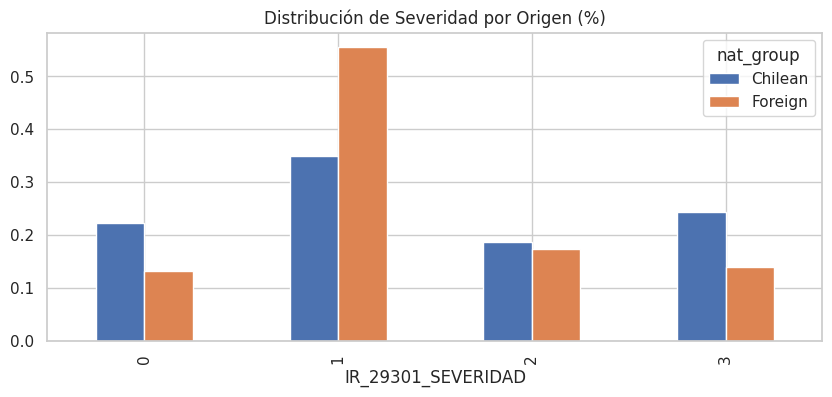

In [5]:
if 'grd_com' in locals() and not grd_com.empty:
    # B.1.1 Top Capítulos
    plt.figure(figsize=(10, 4))
    grd_com["Capítulo"].value_counts().head(10).sort_values().plot(kind="barh", color="purple")
    plt.title("Top 10 Capítulos Diagnósticos (Hospitalización)")
    plt.show()

    # B.2.1 LOS por Nacionalidad
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=grd_com[grd_com["los"] <= 30], x="los", y="nat_group", palette="Set2")
    plt.title("Distribución de Días de Estadía (Truncado a 30 días)")
    plt.show()

    # B.2.2 Severidad
    pd.crosstab(grd_com["IR_29301_SEVERIDAD"], grd_com["nat_group"], normalize='columns').plot(kind="bar", figsize=(10, 4))
    plt.title("Distribución de Severidad por Origen (%)")
    plt.show()

In [6]:
# --- A.4 y B.4 Generación de Tablas Resumen ---
# Mapeo manual de población (basado en tu Tarea 1 o valores aproximados si no tienes el archivo)
pop_map = {13108: 105000, 13127: 190000, 13604: 65000, 13505: 12000}

# Resumen ENO
eno_res = []
for cid, group in eno_com.groupby("codigo_comuna_residencia"):
    cid_int = int(cid)
    pop = pop_map.get(cid_int, 1)
    eno_res.append({
        "codigo_comuna": cid_int,
        "nombre_comuna": nombre_map.get(cid_int),
        "eno_total": len(group),
        "eno_chilean": (group["nacionalidad"] == "Chile").sum(),
        "eno_foreign": (group["nacionalidad"] == "Extranjero").sum(),
        "eno_rate_per_10k": (len(group) / pop) * 10000
    })

# Resumen GRD
grd_res = []
name_to_cut = {"INDEPENDENCIA": 13108, "RECOLETA": 13127, "PADRE HURTADO": 13604, "SAN PEDRO": 13505}
for name, group in grd_com.groupby("COMUNA"):
    cid = name_to_cut.get(name)
    pop = pop_map.get(cid, 1)
    grd_res.append({
        "codigo_comuna": cid,
        "nombre_comuna": nombre_map.get(cid),
        "grd_total": len(group),
        "grd_mean_los": group["los"].mean(),
        "grd_mortality_rate": (group["TIPOALTA"] == "FALLECIDO").mean() * 100,
        "grd_rate_per_10k": (len(group) / pop) * 10000
    })

os.makedirs("output", exist_ok=True)
pd.DataFrame(eno_res).to_csv("output/tarea2_eno_summary.csv", index=False)
pd.DataFrame(grd_res).to_csv("output/tarea2_grd_summary.csv", index=False)

print("¡Tarea 2 finalizada! Tablas guardadas en /output")
display(pd.DataFrame(grd_res))

¡Tarea 2 finalizada! Tablas guardadas en /output


,codigo_comuna,nombre_comuna,grd_total,grd_mean_los,grd_mortality_rate,grd_rate_per_10k
0,13108,Independencia,10573,6.467890,2.856332,1006.952381
1,13604,Padre Hurtado,4764,6.111881,1.910160,732.923077
2,13127,Recoleta,13435,6.329066,2.977298,707.105263
3,13505,San Pedro,1355,4.900369,1.549815,1129.166667
